# 03 — Feature Engineering (representação de texto)

**Anterior:** `02_baseline.ipynb` (referência: **F1 macro = 0.717 ± 0.002**) | **Projeto:** ver `PLANNING.md`

**Objetivo:** medir o impacto de variações da representação de texto sobre a referência, isolando um fator por vez (o refinamento combinatório fica para o grid do notebook 04). Como o destino é uma API de baixa latência, o tamanho do vocabulário é registrado como custo de cada configuração.

| Experimento | Hipótese |
|---|---|
| BoW vs TF-IDF | A ponderação IDF é o principal componente da representação |
| `sublinear_tf` | Ganho marginal |
| `min_df` ∈ {2, 5, 10} | Efeito pequeno; trade-off vocabulário × cobertura |
| n-grams (1,2) | Ganho possível; custo alto de vocabulário |
| Ablação: treino sem textos multi-label | Incerto — menos ruído de rótulo vs menos dados |

**Critério de adoção:** superação consistente da referência (> ~0.005, dado o desvio de ±0.002), ponderada pelo custo de vocabulário.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 110,
})

RANDOM_STATE = 42

## 1. Dados e protocolo

Limpeza, CV e métrica idênticos ao notebook 02 (comparabilidade com a referência). Adicionalmente, marca-se quais textos eram multi-label no train original — insumo da ablação da seção 3.

In [2]:
raw_train = pd.read_csv("../data/raw/medical_tc_train.csv")
test = pd.read_csv("../data/raw/medical_tc_test.csv")

train = raw_train.drop_duplicates(subset="medical_abstract", keep="first")
train = train[~train["medical_abstract"].isin(set(test["medical_abstract"]))]
train = train.reset_index(drop=True)

X_train = train["medical_abstract"]
y_train = train["condition_label"]

labels_por_texto = raw_train.groupby("medical_abstract")["condition_label"].nunique()
amb_texts = set(labels_por_texto[labels_por_texto > 1].index)
is_amb = X_train.isin(amb_texts).to_numpy()

print(f"train limpo: {len(train):,} | textos multi-label na origem: {is_amb.sum():,}"
      f" ({is_amb.mean():.1%})")

train limpo: 8,457 | textos multi-label na origem: 1,850 (21.9%)


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_model(vectorizer):
    """Pipeline com o classificador do baseline fixo; apenas a representação varia."""
    return Pipeline([
        ("vec", vectorizer),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000,
                                   random_state=RANDOM_STATE)),
    ])


def evaluate(vectorizer, name: str, results: dict):
    model = make_model(vectorizer)
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring="f1_macro", n_jobs=-1)
    n_feats = len(vectorizer.fit(X_train).get_feature_names_out())
    results[name] = {
        "f1_macro": scores["test_score"].mean(),
        "std": scores["test_score"].std(),
        "n_features": n_feats,
        "fit_s": scores["fit_time"].mean(),
    }
    r = results[name]
    print(f"{name:<32} F1: {r['f1_macro']:.3f} ± {r['std']:.3f}"
          f" | vocab: {r['n_features']:>7,} | fit: {r['fit_s']:.1f}s")


results = {}

## 2. Experimentos de representação

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

configs = {
    "TF-IDF min_df=5 (referência)": TfidfVectorizer(stop_words="english", min_df=5),
    "BoW min_df=5": CountVectorizer(stop_words="english", min_df=5),
    "TF-IDF sublinear": TfidfVectorizer(stop_words="english", min_df=5,
                                          sublinear_tf=True),
    "TF-IDF min_df=2": TfidfVectorizer(stop_words="english", min_df=2),
    "TF-IDF min_df=10": TfidfVectorizer(stop_words="english", min_df=10),
    "TF-IDF 1-2gram": TfidfVectorizer(stop_words="english", min_df=5,
                                        ngram_range=(1, 2)),
    "TF-IDF 1-2gram sublinear": TfidfVectorizer(stop_words="english", min_df=5,
                                                  ngram_range=(1, 2), sublinear_tf=True),
}

for name, vec in configs.items():
    evaluate(vec, name, results)

TF-IDF min_df=5 (referência)     F1: 0.717 ± 0.002 | vocab:  10,635 | fit: 0.6s


BoW min_df=5                     F1: 0.653 ± 0.002 | vocab:  10,635 | fit: 0.8s


TF-IDF sublinear                 F1: 0.718 ± 0.007 | vocab:  10,635 | fit: 0.6s


TF-IDF min_df=2                  F1: 0.720 ± 0.005 | vocab:  19,109 | fit: 0.7s


TF-IDF min_df=10                 F1: 0.711 ± 0.004 | vocab:   6,892 | fit: 0.5s


TF-IDF 1-2gram                   F1: 0.723 ± 0.007 | vocab:  25,751 | fit: 1.4s


TF-IDF 1-2gram sublinear         F1: 0.720 ± 0.004 | vocab:  25,751 | fit: 1.3s


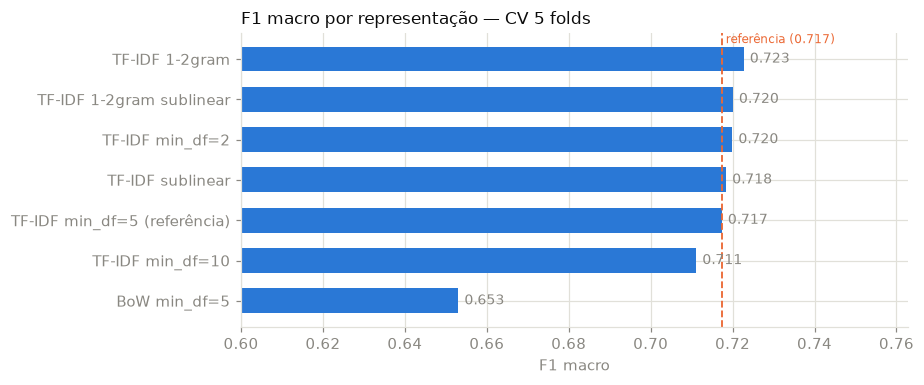

,f1_macro,std,n_features,fit_s
BoW min_df=5,0.653,0.002,10635.0,0.764
TF-IDF min_df=10,0.711,0.004,6892.0,0.512
TF-IDF min_df=5 (referência),0.717,0.002,10635.0,0.634
TF-IDF sublinear,0.718,0.007,10635.0,0.615
TF-IDF min_df=2,0.720,0.005,19109.0,0.712
TF-IDF 1-2gram sublinear,0.720,0.004,25751.0,1.307
TF-IDF 1-2gram,0.723,0.007,25751.0,1.395


In [5]:
summary = pd.DataFrame(results).T.sort_values("f1_macro")
REF = results["TF-IDF min_df=5 (referência)"]["f1_macro"]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
bars = ax.barh(summary.index, summary["f1_macro"], color=BLUE, height=0.62)
ax.bar_label(bars, fmt="%.3f", fontsize=9, color=MUTED, padding=4)
ax.axvline(REF, color=ORANGE, linewidth=1.2, linestyle="--")
ax.text(REF, ax.get_ylim()[1], f" referência ({REF:.3f})", color=ORANGE,
        fontsize=8, va="top", ha="left")
ax.set_title("F1 macro por representação — CV 5 folds", loc="left", fontsize=11)
ax.set_xlim(0.60, max(summary["f1_macro"]) + 0.04)
ax.set_xlabel("F1 macro")
plt.tight_layout()
plt.show()

summary.round(3)

## 3. Ablação: treino sem os textos multi-label

Os 21,9% de textos multi-label na origem carregam, após a deduplicação, um rótulo arbitrário. A ablação mede se removê-los do treino melhora o desempenho.

**Desenho experimental:** o filtro é aplicado **apenas ao lado de treino de cada fold**; os folds de validação permanecem completos e idênticos aos dos demais experimentos. Aplicar `cross_validate` diretamente ao subconjunto filtrado alteraria também a validação (conjunto mais fácil, sem os textos ambíguos), invalidando a comparação com a referência. Como essa configuração não é suportada pelo `cross_validate`, o loop de CV é implementado explicitamente.

In [6]:
from sklearn.base import clone
from sklearn.metrics import f1_score

best_name = max(results, key=lambda k: results[k]["f1_macro"])
print(f"Base do experimento (melhor representação): {best_name}\n")
best_vec = configs[best_name]

f1s = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    keep = tr_idx[~is_amb[tr_idx]]               # filtro aplicado só ao treino do fold
    model = clone(make_model(best_vec))
    model.fit(X_train.iloc[keep], y_train.iloc[keep])
    pred = model.predict(X_train.iloc[va_idx])   # validação no fold completo
    f1s.append(f1_score(y_train.iloc[va_idx], pred, average="macro"))
    print(f"fold {fold}: treino {len(keep):,} (de {len(tr_idx):,}) | F1 {f1s[-1]:.3f}")

f1s = np.array(f1s)
print(f"\nSem textos multi-label no treino: F1 {f1s.mean():.3f} ± {f1s.std():.3f}")
print(f"Com todos os textos (referência):  F1 {results[best_name]['f1_macro']:.3f}"
      f" ± {results[best_name]['std']:.3f}")

Base do experimento (melhor representação): TF-IDF 1-2gram



fold 1: treino 5,282 (de 6,765) | F1 0.725


fold 2: treino 5,293 (de 6,765) | F1 0.732


fold 3: treino 5,283 (de 6,766) | F1 0.720


fold 4: treino 5,285 (de 6,766) | F1 0.709


fold 5: treino 5,285 (de 6,766) | F1 0.715

Sem textos multi-label no treino: F1 0.720 ± 0.008
Com todos os textos (referência):  F1 0.723 ± 0.007


## 4. Síntese

| Configuração | F1 macro | Vocabulário |
|---|---|---|
| BoW min_df=5 | 0.653 ± 0.002 | 10.635 |
| TF-IDF min_df=10 | 0.711 ± 0.004 | 6.892 |
| **TF-IDF min_df=5 (referência)** | **0.717 ± 0.002** | 10.635 |
| TF-IDF sublinear | 0.718 ± 0.007 | 10.635 |
| TF-IDF min_df=2 | 0.720 ± 0.005 | 19.109 |
| TF-IDF 1-2gram sublinear | 0.720 ± 0.004 | 25.751 |
| TF-IDF 1-2gram | 0.723 ± 0.007 | 25.751 |

1. **A ponderação IDF é o componente dominante da representação:** sua remoção (BoW) custa −0.064 — uma ordem de grandeza acima de qualquer outro efeito medido.
2. **Nenhuma variação supera a referência de forma conclusiva.** O melhor candidato (1-2gram, +0.006, σ ±0.007) fica dentro do ruído e custa 2,4x mais vocabulário e ~2x mais tempo de fit — custo-benefício desfavorável sob o critério de latência.
3. **Ablação dos textos multi-label: rejeitada.** 0.720 ± 0.008 sem eles vs 0.723 ± 0.007 com todos (empate técnico); mantê-los preserva dados e simplifica o pipeline.
4. **Decisão:** a representação segue **TF-IDF unigrama, min_df=5, stop-words**; `ngram_range` e `min_df` entram no grid do notebook 04 para otimização conjunta com a regularização, dado que interagem com o C ótimo.

**Próximo:** `04_model_selection.ipynb` — comparação de classificadores, tuning e avaliação final no test set.